# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Data paths
processed_data_path = Path('../data/processed')

## 1. Load Cleaned Data

In [2]:
# Load cleaned datasets
df_student_info = pd.read_csv(processed_data_path / 'student_info_clean.csv')
df_student_registration = pd.read_csv(processed_data_path / 'student_registration_clean.csv')
df_student_vle = pd.read_csv(processed_data_path / 'student_vle_clean.csv')
df_assessments = pd.read_csv(processed_data_path / 'assessments_clean.csv')
df_student_assessment = pd.read_csv(processed_data_path / 'student_assessment_clean.csv')
df_vle = pd.read_csv(processed_data_path / 'vle_clean.csv')

# Load integrated datasets
df_student_profile = pd.read_csv(processed_data_path / 'student_profile.csv')
df_student_vle_summary = pd.read_csv(processed_data_path / 'student_vle_summary.csv')
df_assessment_perf = pd.read_csv(processed_data_path / 'assessment_performance.csv')

print(f"\nDataset shapes:")
print(f"  - Student Info: {df_student_info.shape}")
print(f"  - Student Registration: {df_student_registration.shape}")
print(f"  - Student VLE: {df_student_vle.shape}")
print(f"  - Assessments: {df_assessments.shape}")
print(f"  - Student Assessment: {df_student_assessment.shape}")
print(f"  - VLE: {df_vle.shape}")
print(f"  - Student Profile: {df_student_profile.shape}")
print(f"  - Student VLE Summary: {df_student_vle_summary.shape}")
print(f"  - Assessment Performance: {df_assessment_perf.shape}")


Dataset shapes:
  - Student Info: (28785, 12)
  - Student Registration: (32593, 5)
  - Student VLE: (10655280, 6)
  - Assessments: (206, 6)
  - Student Assessment: (173912, 5)
  - VLE: (6364, 6)
  - Student Profile: (28785, 14)
  - Student VLE Summary: (29228, 8)
  - Assessment Performance: (173912, 10)


## 2. Target Variable Analysis - Student Outcomes

In [3]:
# Target variable distribution
final_result_counts = df_student_info['final_result'].value_counts()
final_result_pct = df_student_info['final_result'].value_counts(normalize=True) * 100

print("Student Outcomes Distribution:")
print("=" * 50)
for outcome in final_result_counts.index:
    count = final_result_counts[outcome]
    pct = final_result_pct[outcome]
    print(f"{outcome:15s}: {count:5d} ({pct:5.1f}%)")

print(f"\n{'At-Risk Students (Withdrawn + Fail)':30s}")
print("=" * 50)
at_risk = df_student_info[df_student_info['final_result'].isin(['Withdrawn', 'Fail'])]
at_risk_count = len(at_risk)
at_risk_pct = (at_risk_count / len(df_student_info)) * 100
print(f"Total At-Risk: {at_risk_count} ({at_risk_pct:.1f}%)")
print(f"Withdrawn: {(df_student_info['final_result'] == 'Withdrawn').sum()} ({(df_student_info['final_result'] == 'Withdrawn').sum()/len(df_student_info)*100:.1f}%)")
print(f"Failed: {(df_student_info['final_result'] == 'Fail').sum()} ({(df_student_info['final_result'] == 'Fail').sum()/len(df_student_info)*100:.1f}%)")

Student Outcomes Distribution:
Pass           : 10833 ( 37.6%)
Withdrawn      :  9043 ( 31.4%)
Fail           :  6264 ( 21.8%)
Distinction    :  2645 (  9.2%)

At-Risk Students (Withdrawn + Fail)
Total At-Risk: 15307 (53.2%)
Withdrawn: 9043 (31.4%)
Failed: 6264 (21.8%)


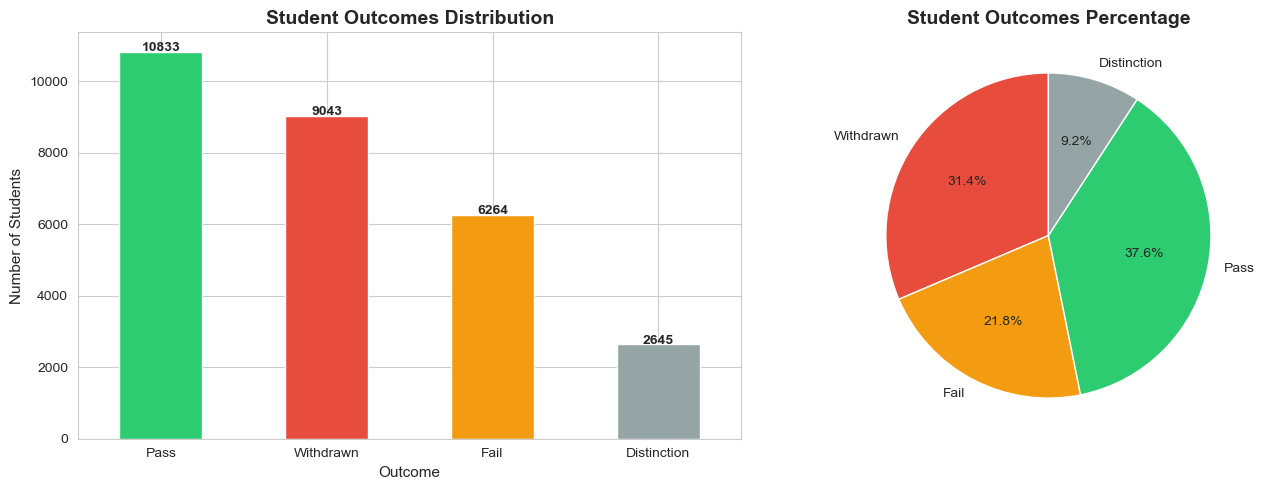

In [4]:
# Visualize target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']
final_result_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Student Outcomes Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Students', fontsize=11)
axes[0].set_xlabel('Outcome', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(final_result_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
colors_pie = ['#e74c3c', '#f39c12', '#2ecc71', '#95a5a6']
outcome_order = ['Withdrawn', 'Fail', 'Pass', 'Distinction']
values = [final_result_counts.get(outcome, 0) for outcome in outcome_order]
axes[1].pie(values, labels=outcome_order, autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title('Student Outcomes Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Student Demographics Analysis

In [5]:
print("Demographic Distribution:")
print("=" * 50)

print("\n1. GENDER Distribution:")
gender_dist = df_student_info['gender'].value_counts()
for gender, count in gender_dist.items():
    pct = (count / len(df_student_info)) * 100
    print(f"   {gender:20s}: {count:5d} ({pct:5.1f}%)")

print("\n2. AGE BAND Distribution:")
age_order = ['Under 20', '20-25', '25-30', '30-35', '35-55', '55<=']
age_dist = df_student_info['age_band'].value_counts().reindex(age_order, fill_value=0)
for age, count in age_dist.items():
    pct = (count / len(df_student_info)) * 100 if count > 0 else 0
    print(f"   {age:20s}: {count:5d} ({pct:5.1f}%)")

print("\n3. EDUCATION Level Distribution:")
edu_dist = df_student_info['highest_education'].value_counts()
for edu, count in edu_dist.items():
    pct = (count / len(df_student_info)) * 100
    print(f"   {edu:20s}: {count:5d} ({pct:5.1f}%)")

print("\n4. DISABILITY Status:")
disability_dist = df_student_info['disability'].value_counts()
for disability, count in disability_dist.items():
    pct = (count / len(df_student_info)) * 100
    print(f"   {disability:20s}: {count:5d} ({pct:5.1f}%)")

Demographic Distribution:

1. GENDER Distribution:
   M                   : 15046 ( 52.3%)
   F                   : 13739 ( 47.7%)

2. AGE BAND Distribution:
   Under 20            :     0 (  0.0%)
   20-25               :     0 (  0.0%)
   25-30               :     0 (  0.0%)
   30-35               :     0 (  0.0%)
   35-55               :  8462 ( 29.4%)
   55<=                :   178 (  0.6%)

3. EDUCATION Level Distribution:
   A Level or Equivalent: 12355 ( 42.9%)
   Lower Than A Level  : 11780 ( 40.9%)
   HE Qualification    :  4092 ( 14.2%)
   No Formal quals     :   306 (  1.1%)
   Post Graduate Qualification:   252 (  0.9%)

4. DISABILITY Status:
   N                   : 26068 ( 90.6%)
   Y                   :  2717 (  9.4%)


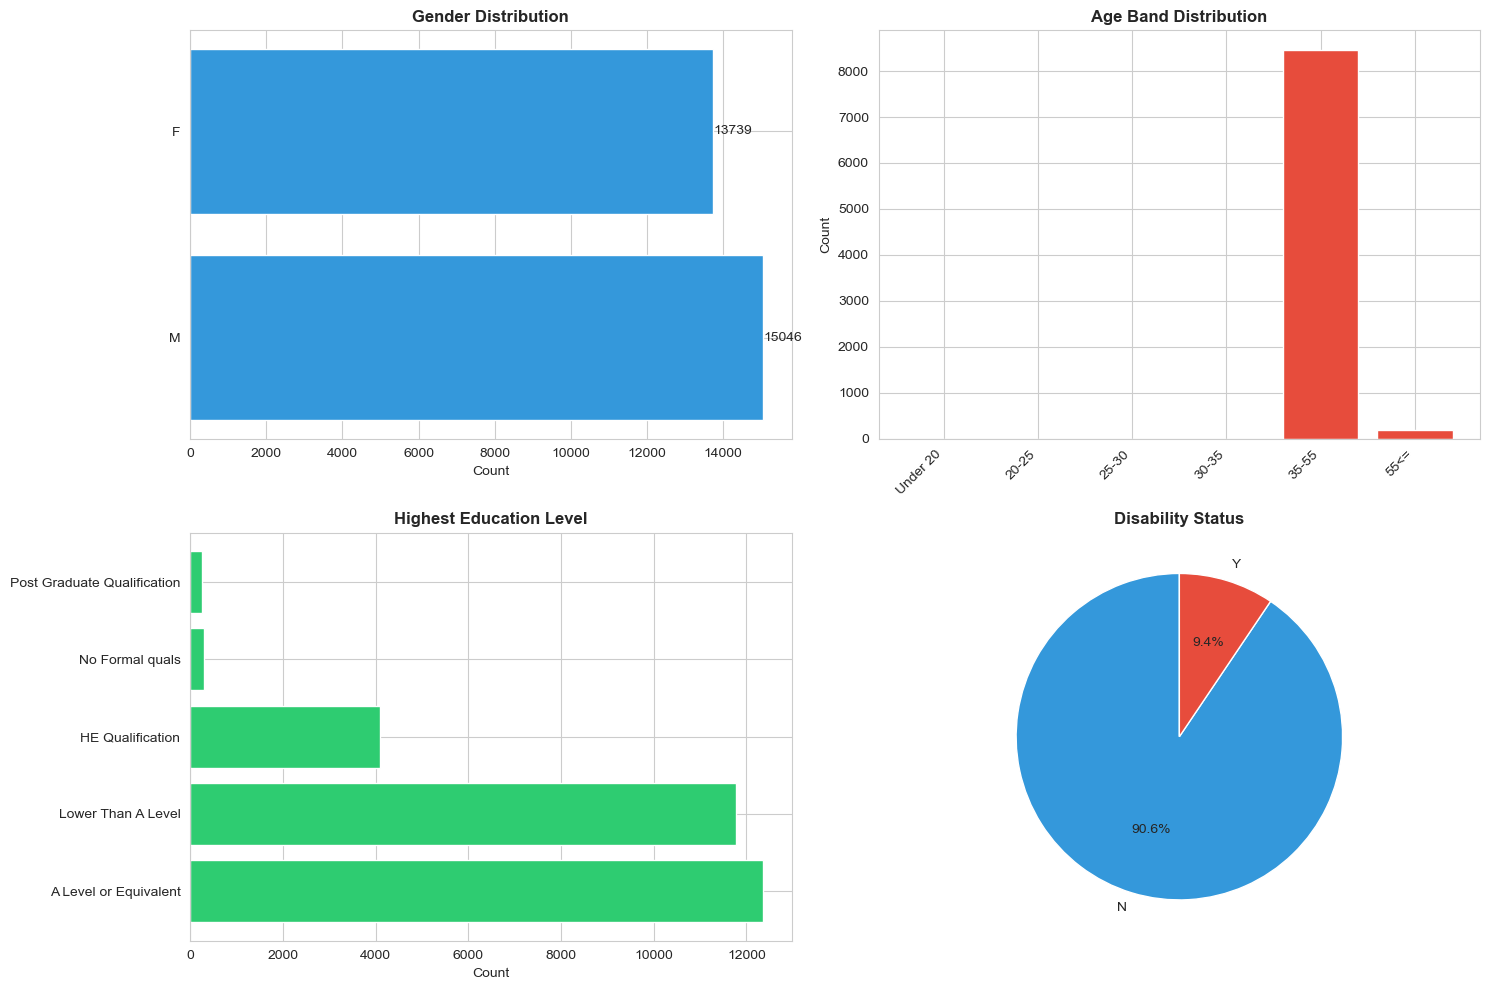

In [6]:
# Demographics visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gender distribution
gender_data = df_student_info['gender'].value_counts()
axes[0, 0].barh(gender_data.index, gender_data.values, color='#3498db')
axes[0, 0].set_title('Gender Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Count')
for i, v in enumerate(gender_data.values):
    axes[0, 0].text(v + 10, i, str(v), va='center')

# Age band distribution
age_order = ['Under 20', '20-25', '25-30', '30-35', '35-55', '55<=']
age_data = df_student_info['age_band'].value_counts().reindex(age_order, fill_value=0)
axes[0, 1].bar(range(len(age_data)), age_data.values, color='#e74c3c')
axes[0, 1].set_xticks(range(len(age_data)))
axes[0, 1].set_xticklabels(age_data.index, rotation=45, ha='right')
axes[0, 1].set_title('Age Band Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# Education level distribution
edu_data = df_student_info['highest_education'].value_counts()
axes[1, 0].barh(edu_data.index, edu_data.values, color='#2ecc71')
axes[1, 0].set_title('Highest Education Level', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Count')

# Disability status
disability_data = df_student_info['disability'].value_counts()
axes[1, 1].pie(disability_data.values, labels=disability_data.index, autopct='%1.1f%%', 
               colors=['#3498db', '#e74c3c'], startangle=90)
axes[1, 1].set_title('Disability Status', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.1 Academic Background Distribution
Distribution of learners by course module, number of retakes, number of credits, region, age, and educational level

Academic profile distribution (module/re-attempt/credits/region):

1. Number of previous attempts:
num_of_prev_attempts
0    26055
1     2155
2      440
3       97
4       27
5        9
6        2
Name: count, dtype: int64

2. Studied credits summary:
count    28785.000000
mean        78.691506
std         40.617665
min         30.000000
25%         60.000000
50%         60.000000
75%        120.000000
max        655.000000
Name: studied_credits, dtype: float64

3. Top regions by student count:
region
East Anglian Region     3000
Scotland                2934
London Region           2845
South Region            2737
North Western Region    2548
West Midlands Region    2269
South West Region       2154
East Midlands Region    2095
Wales                   1876
South East Region       1875
Name: count, dtype: int64

4. Module enrollment distribution:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64


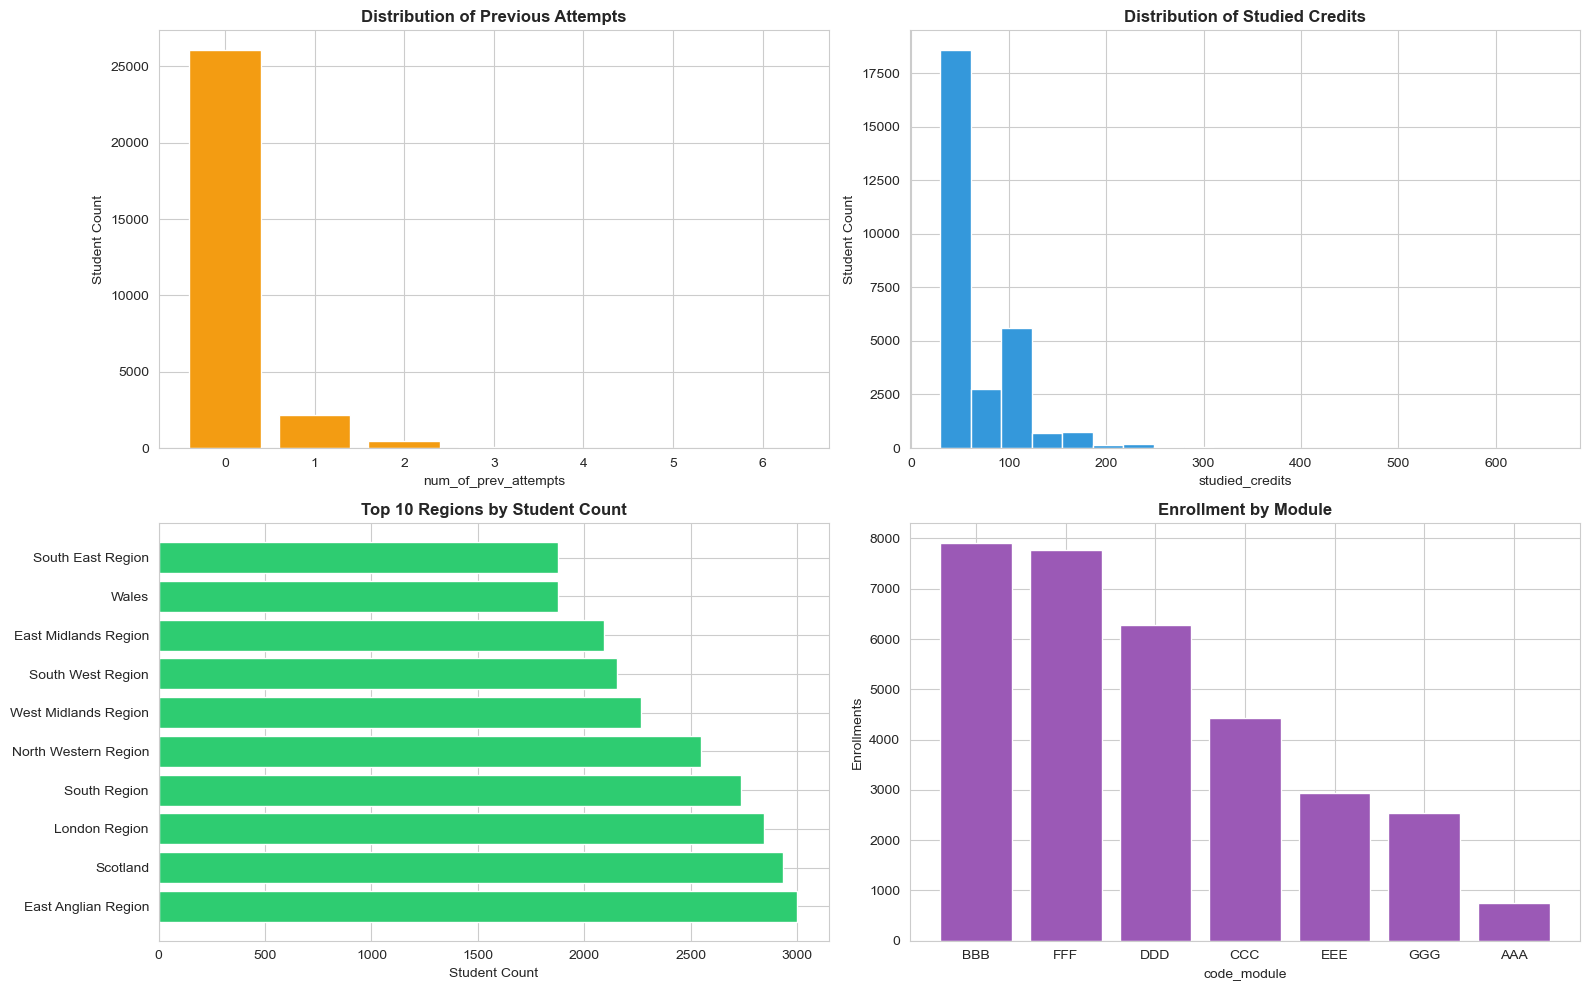

In [7]:
# Academic profile requested in assignment
print('Academic profile distribution (module/re-attempt/credits/region):')
print('=' * 70)

print('\n1. Number of previous attempts:')
prev_attempt_dist = df_student_info['num_of_prev_attempts'].value_counts().sort_index()
print(prev_attempt_dist)

print('\n2. Studied credits summary:')
print(df_student_info['studied_credits'].describe())

print('\n3. Top regions by student count:')
region_dist = df_student_info['region'].value_counts().head(10)
print(region_dist)

print('\n4. Module enrollment distribution:')
module_enroll = df_student_registration['code_module'].value_counts().sort_values(ascending=False)
print(module_enroll)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Previous attempts
axes[0, 0].bar(prev_attempt_dist.index.astype(str), prev_attempt_dist.values, color='#f39c12')
axes[0, 0].set_title('Distribution of Previous Attempts', fontweight='bold')
axes[0, 0].set_xlabel('num_of_prev_attempts')
axes[0, 0].set_ylabel('Student Count')

# Studied credits histogram
axes[0, 1].hist(df_student_info['studied_credits'], bins=20, color='#3498db', edgecolor='white')
axes[0, 1].set_title('Distribution of Studied Credits', fontweight='bold')
axes[0, 1].set_xlabel('studied_credits')
axes[0, 1].set_ylabel('Student Count')

# Region top 10
axes[1, 0].barh(region_dist.index, region_dist.values, color='#2ecc71')
axes[1, 0].set_title('Top 10 Regions by Student Count', fontweight='bold')
axes[1, 0].set_xlabel('Student Count')

# Module enrollment
axes[1, 1].bar(module_enroll.index, module_enroll.values, color='#9b59b6')
axes[1, 1].set_title('Enrollment by Module', fontweight='bold')
axes[1, 1].set_xlabel('code_module')
axes[1, 1].set_ylabel('Enrollments')

plt.tight_layout()
plt.show()

## 4. VLE (Virtual Learning Environment) Engagement Analysis

In [8]:
# VLE engagement analysis
print("VLE (Virtual Learning Environment) Engagement:")
print("=" * 60)

print("\n1. VLE Clicks Statistics (Overall):")
vle_stats = df_student_vle['sum_click'].describe()
print(vle_stats)

print("\n2. Activity Type Distribution in VLE:")
activity_dist = df_vle['activity_type'].value_counts()
for activity, count in activity_dist.items():
    pct = (count / len(df_vle)) * 100
    print(f"   {activity:25s}: {count:4d} ({pct:5.1f}%)")

# Merge student_vle with student_info to analyze by outcome
vle_by_outcome = df_student_vle.merge(
    df_student_info[['id_student', 'final_result']], 
    on='id_student'
)

print("\n3. VLE Engagement by Student Outcome:")
print("-" * 60)
for outcome in ['Pass', 'Distinction', 'Fail', 'Withdrawn']:
    outcome_data = vle_by_outcome[vle_by_outcome['final_result'] == outcome]['sum_click']
    if len(outcome_data) > 0:
        print(f"\n{outcome}:")
        print(f"   Mean clicks:  {outcome_data.mean():8.1f}")
        print(f"   Median clicks:{outcome_data.median():8.1f}")
        print(f"   Std dev:      {outcome_data.std():8.1f}")
        print(f"   Min - Max:    {outcome_data.min():.0f} - {outcome_data.max():.0f}")

VLE (Virtual Learning Environment) Engagement:

1. VLE Clicks Statistics (Overall):
count    1.065528e+07
mean     3.716946e+00
std      8.849047e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      6.977000e+03
Name: sum_click, dtype: float64

2. Activity Type Distribution in VLE:
   resource                 : 2660 ( 41.8%)
   subpage                  : 1055 ( 16.6%)
   oucontent                :  996 ( 15.7%)
   url                      :  886 ( 13.9%)
   forumng                  :  194 (  3.0%)
   quiz                     :  127 (  2.0%)
   page                     :  102 (  1.6%)
   oucollaborate            :   82 (  1.3%)
   questionnaire            :   61 (  1.0%)
   ouwiki                   :   49 (  0.8%)
   dataplus                 :   28 (  0.4%)
   externalquiz             :   26 (  0.4%)
   homepage                 :   22 (  0.3%)
   glossary                 :   21 (  0.3%)
   ouelluminate             :   21 (  0.3%)
   dualpa

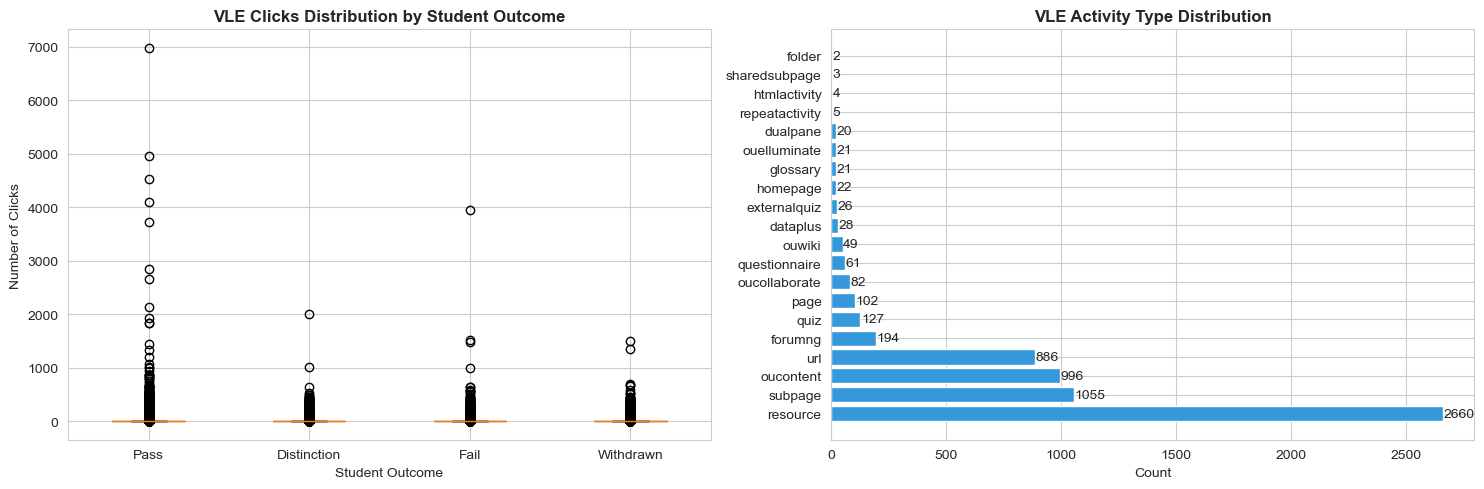

In [9]:
# VLE visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot of VLE clicks by outcome
outcome_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
data_to_plot = [
    vle_by_outcome[vle_by_outcome['final_result'] == outcome]['sum_click'].values 
    for outcome in outcome_order
]

bp = axes[0].boxplot(data_to_plot, labels=outcome_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('VLE Clicks Distribution by Student Outcome', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Clicks')
axes[0].set_xlabel('Student Outcome')

# Activity type distribution
activity_dist = df_vle['activity_type'].value_counts()
axes[1].barh(activity_dist.index, activity_dist.values, color='#3498db')
axes[1].set_title('VLE Activity Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(activity_dist.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.show()

## 4.1 Time-Series Interaction Analysis
Analyze by day/week, identify periods of decreased engagement, and determine the most frequently used learning materials

Time-series summary
Day range: -25 to 269
Week range: -4 to 38

Top 10 material types by total clicks:
activity_type
oucontent        11206803
forumng           7973390
quiz              6981240
homepage          6949064
subpage           3411582
resource          1110132
ouwiki             894512
url                566702
oucollaborate      108974
glossary            87962
Name: sum_click, dtype: int64

Average clicks by phase:
              phase  mean_clicks
0      Early (W<=1)     3.390651
1   Build-up (W2-5)     3.713835
2    Middle (W6-10)     3.531292
3     Late (W11-20)     3.701587
4  Very late (W>20)     4.011156


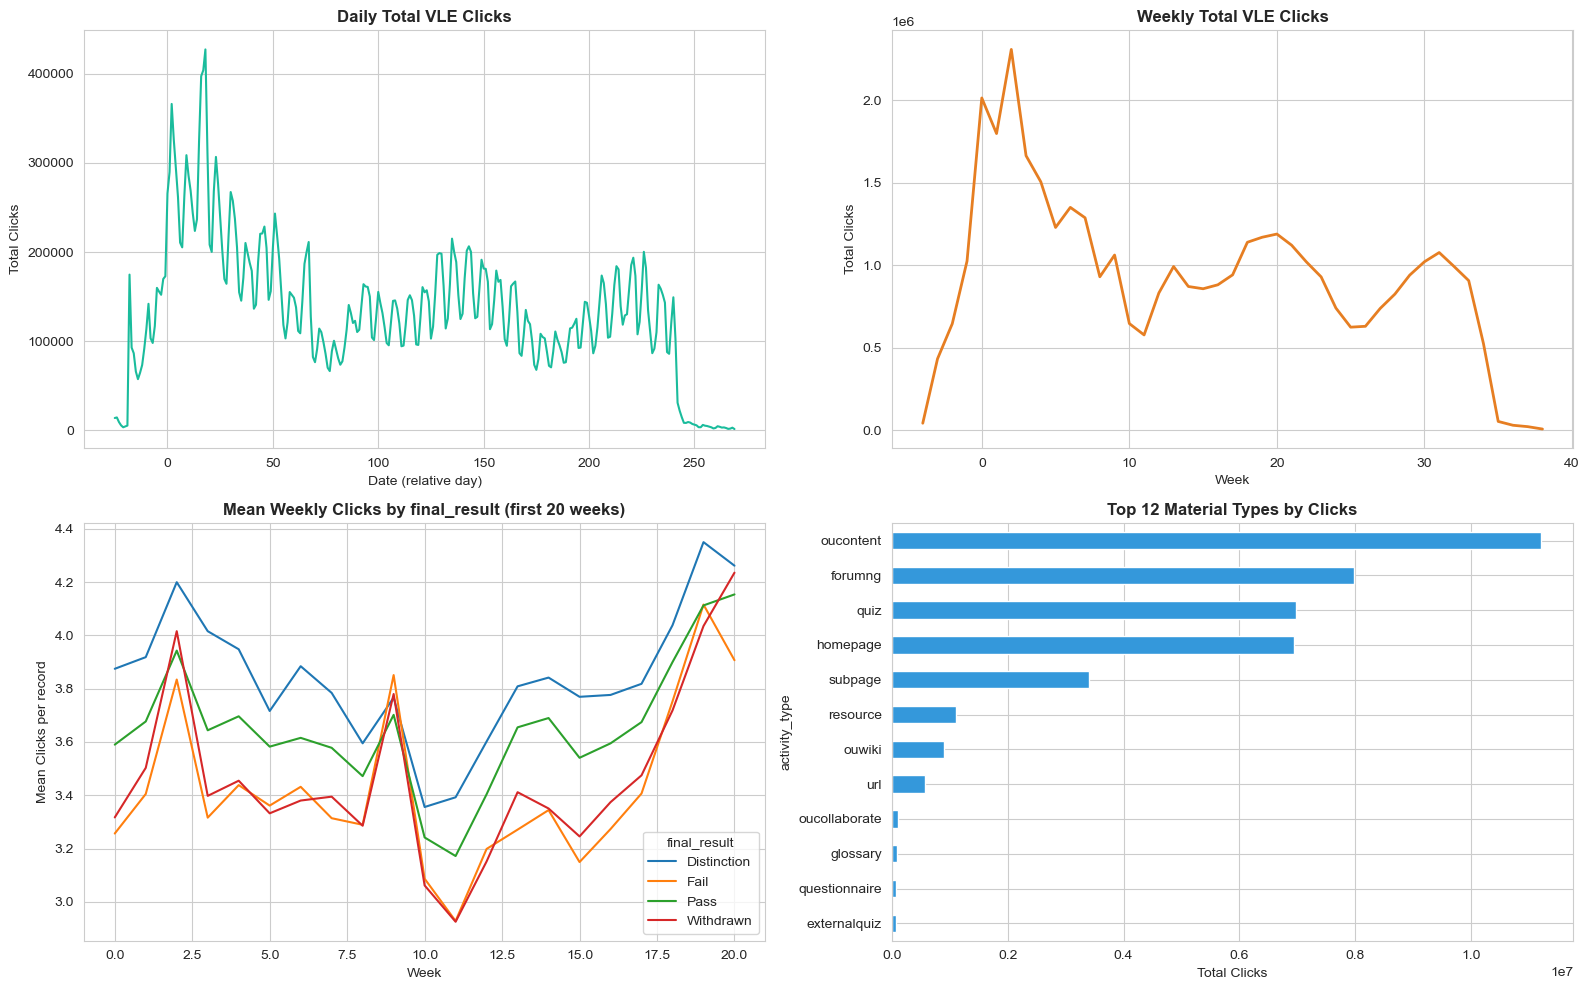

In [10]:
# Time-series interaction analysis by day/week and material type
vle_ts = df_student_vle.merge(
    df_student_info[['id_student', 'final_result']],
    on='id_student',
    how='left'
).merge(
    df_vle[['id_site', 'activity_type']],
    on='id_site',
    how='left'
)

vle_ts['week'] = (vle_ts['date'] // 7).astype(int)

daily_clicks = vle_ts.groupby('date')['sum_click'].sum().reset_index(name='total_clicks')
weekly_clicks = vle_ts.groupby('week')['sum_click'].sum().reset_index(name='total_clicks')
weekly_by_result = vle_ts.groupby(['week', 'final_result'])['sum_click'].mean().reset_index(name='mean_clicks')

# Define course phases based on week windows
vle_ts['phase'] = pd.cut(
    vle_ts['week'],
    bins=[-100, 1, 5, 10, 20, 100],
    labels=['Early (W<=1)', 'Build-up (W2-5)', 'Middle (W6-10)', 'Late (W11-20)', 'Very late (W>20)']
)
phase_clicks = vle_ts.groupby('phase', observed=False)['sum_click'].mean().reset_index(name='mean_clicks')

material_usage = vle_ts.groupby('activity_type')['sum_click'].sum().sort_values(ascending=False)

print('Time-series summary')
print('=' * 60)
print(f"Day range: {vle_ts['date'].min()} to {vle_ts['date'].max()}")
print(f"Week range: {vle_ts['week'].min()} to {vle_ts['week'].max()}")
print('\nTop 10 material types by total clicks:')
print(material_usage.head(10))
print('\nAverage clicks by phase:')
print(phase_clicks)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_clicks['date'], daily_clicks['total_clicks'], color='#1abc9c', linewidth=1.5)
axes[0, 0].set_title('Daily Total VLE Clicks', fontweight='bold')
axes[0, 0].set_xlabel('Date (relative day)')
axes[0, 0].set_ylabel('Total Clicks')

axes[0, 1].plot(weekly_clicks['week'], weekly_clicks['total_clicks'], color='#e67e22', linewidth=2)
axes[0, 1].set_title('Weekly Total VLE Clicks', fontweight='bold')
axes[0, 1].set_xlabel('Week')
axes[0, 1].set_ylabel('Total Clicks')

sns.lineplot(
    data=weekly_by_result[weekly_by_result['week'].between(0, 20)],
    x='week', y='mean_clicks', hue='final_result',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Mean Weekly Clicks by final_result (first 20 weeks)', fontweight='bold')
axes[1, 0].set_xlabel('Week')
axes[1, 0].set_ylabel('Mean Clicks per record')

material_usage.head(12).sort_values().plot(kind='barh', ax=axes[1, 1], color='#3498db')
axes[1, 1].set_title('Top 12 Material Types by Clicks', fontweight='bold')
axes[1, 1].set_xlabel('Total Clicks')

plt.tight_layout()
plt.show()

Early-warning comparison (first 4 weeks)

Early assessment score by final_result:
                   mean  median  count
final_result                          
Distinction   86.489606    90.0   2790
Pass          76.744147    80.0  10850
Fail          68.053649    71.0   4865
Withdrawn     66.665281    72.0   5052

Unique students with submission in first 4 weeks:
final_result
Pass           8864
Fail           4084
Withdrawn      4020
Distinction    2079
Name: id_student, dtype: int64


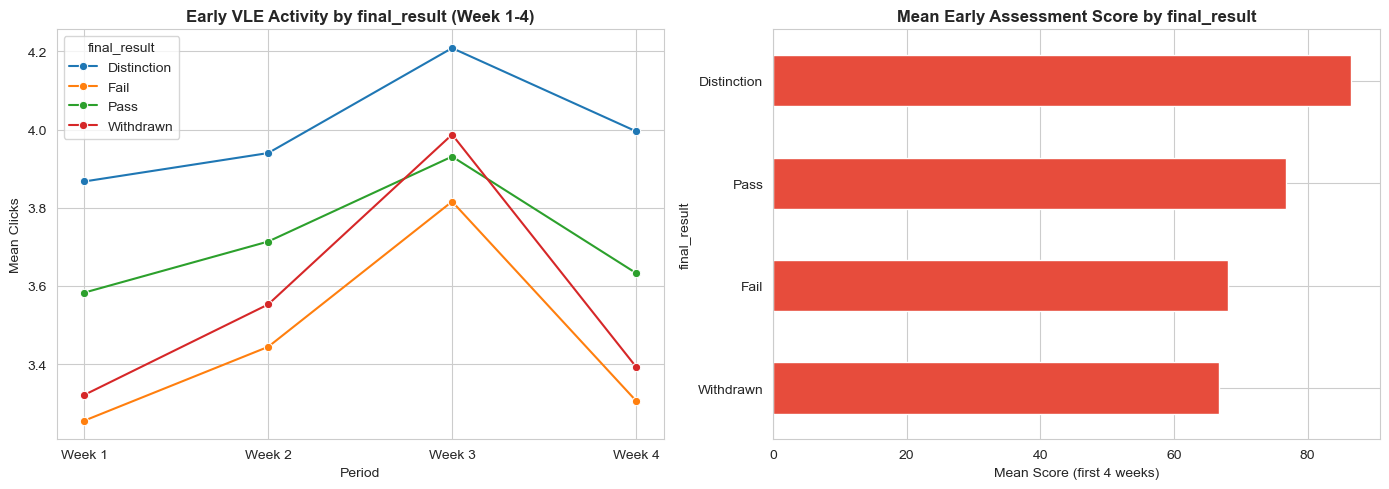

In [11]:
# Early-warning signals: compare final_result groups in early timeline
early_vle = vle_ts[vle_ts['date'].between(0, 28)].copy()
early_vle['period'] = pd.cut(
    early_vle['date'],
    bins=[-1, 7, 14, 21, 28],
    labels=['Week 1', 'Week 2', 'Week 3', 'Week 4']
)

early_click_pattern = early_vle.groupby(['period', 'final_result'])['sum_click'].mean().reset_index(name='mean_clicks')

early_assess = df_student_assessment.merge(
    df_assessments[['id_assessment', 'assessment_type']],
    on='id_assessment',
    how='left'
).merge(
    df_student_info[['id_student', 'final_result']],
    on='id_student',
    how='left'
)
early_assess_28 = early_assess[early_assess['date_submitted'].between(0, 28)]

score_early = early_assess_28.groupby('final_result')['score'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
submission_early = early_assess_28.groupby('final_result')['id_student'].nunique().sort_values(ascending=False)

print('Early-warning comparison (first 4 weeks)')
print('=' * 60)
print('\nEarly assessment score by final_result:')
print(score_early)
print('\nUnique students with submission in first 4 weeks:')
print(submission_early)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=early_click_pattern, x='period', y='mean_clicks', hue='final_result', marker='o', ax=axes[0])
axes[0].set_title('Early VLE Activity by final_result (Week 1-4)', fontweight='bold')
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Mean Clicks')

score_early['mean'].sort_values().plot(kind='barh', color='#e74c3c', ax=axes[1])
axes[1].set_title('Mean Early Assessment Score by final_result', fontweight='bold')
axes[1].set_xlabel('Mean Score (first 4 weeks)')

plt.tight_layout()
plt.show()

## 5. Assessment Performance Analysis

In [12]:
# Assessment performance analysis
print("Assessment Performance:")
print("=" * 60)

print("\n1. Assessment Type Distribution:")
assess_type_dist = df_assessments['assessment_type'].value_counts()
for assess_type, count in assess_type_dist.items():
    pct = (count / len(df_assessments)) * 100
    print(f"   {assess_type:15s}: {count:3d} ({pct:5.1f}%)")

print("\n2. Overall Score Statistics:")
score_stats = df_student_assessment['score'].describe()
print(score_stats)

# Analysis by outcome
assess_by_outcome = df_student_assessment.merge(
    df_student_info[['id_student', 'final_result']], 
    on='id_student'
)

print("\n3. Assessment Score by Student Outcome:")
print("-" * 60)
for outcome in ['Pass', 'Distinction', 'Fail', 'Withdrawn']:
    outcome_scores = assess_by_outcome[assess_by_outcome['final_result'] == outcome]['score']
    if len(outcome_scores) > 0:
        print(f"\n{outcome}:")
        print(f"   Mean score:   {outcome_scores.mean():7.2f}")
        print(f"   Median score: {outcome_scores.median():7.2f}")
        print(f"   Std dev:      {outcome_scores.std():7.2f}")
        print(f"   Min - Max:    {outcome_scores.min():.0f} - {outcome_scores.max():.0f}")

print("\n4. Assessment Submission Rate by Type:")
print("-" * 60)
for assess_type in assess_type_dist.index:
    submissions = len(
        df_student_assessment[
            df_student_assessment['id_assessment'].isin(
                df_assessments[df_assessments['assessment_type'] == assess_type]['id_assessment']
            )
        ]
    )
    potential_assessments = (
        len(df_student_registration) * 
        len(df_assessments[df_assessments['assessment_type'] == assess_type])
    )
    submission_rate = (submissions / potential_assessments * 100) if potential_assessments > 0 else 0
    print(f"{assess_type:15s}: {submission_rate:6.2f}%")

Assessment Performance:

1. Assessment Type Distribution:
   TMA            : 106 ( 51.5%)
   CMA            :  76 ( 36.9%)
   Exam           :  24 ( 11.7%)

2. Overall Score Statistics:
count    173912.000000
mean         75.724171
std          18.940093
min           0.000000
25%          65.000000
50%          80.000000
75%          90.000000
max         100.000000
Name: score, dtype: float64

3. Assessment Score by Student Outcome:
------------------------------------------------------------

Pass:
   Mean score:     76.95
   Median score:   80.00
   Std dev:        16.51
   Min - Max:    0 - 100

Distinction:
   Mean score:     88.66
   Median score:   91.00
   Std dev:        11.48
   Min - Max:    0 - 100

Fail:
   Mean score:     65.15
   Median score:   67.00
   Std dev:        21.52
   Min - Max:    0 - 100

Withdrawn:
   Mean score:     68.71
   Median score:   73.00
   Std dev:        22.09
   Min - Max:    0 - 100

4. Assessment Submission Rate by Type:
-------------------

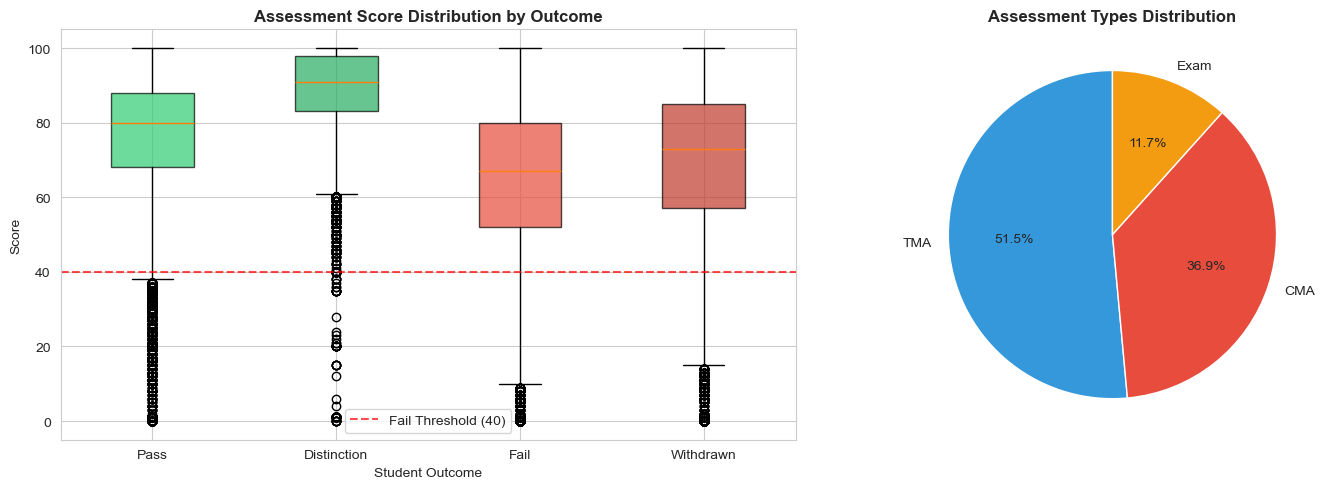

In [13]:
# Assessment visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Score distribution by outcome
outcome_order = ['Pass', 'Distinction', 'Fail', 'Withdrawn']
score_to_plot = [
    assess_by_outcome[assess_by_outcome['final_result'] == outcome]['score'].values 
    for outcome in outcome_order
]

bp = axes[0].boxplot(score_to_plot, labels=outcome_order, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Assessment Score Distribution by Outcome', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Student Outcome')
axes[0].axhline(y=40, color='red', linestyle='--', label='Fail Threshold (40)', alpha=0.7)
axes[0].legend()

# Assessment type distribution
assess_type_data = df_assessments['assessment_type'].value_counts()
axes[1].pie(assess_type_data.values, labels=assess_type_data.index, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c', '#f39c12'], startangle=90)
axes[1].set_title('Assessment Types Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. At-Risk Student Profiling

In [14]:
# Create at-risk label
df_at_risk = df_student_info.copy()
df_at_risk['is_at_risk'] = df_at_risk['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

print("At-Risk Student Characteristics:")
print("=" * 60)

print(f"\nTotal At-Risk Students: {df_at_risk['is_at_risk'].sum()} ({df_at_risk['is_at_risk'].mean()*100:.1f}%)")

# Demographics of at-risk students
print("\n1. At-Risk Rate by GENDER:")
gender_at_risk = df_at_risk.groupby('gender')['is_at_risk'].agg(['sum', 'count', 'mean'])
gender_at_risk.columns = ['At-Risk Count', 'Total', 'At-Risk %']
gender_at_risk['At-Risk %'] = gender_at_risk['At-Risk %'] * 100
print(gender_at_risk)

print("\n2. At-Risk Rate by AGE BAND:")
age_order = ['Under 20', '20-25', '25-30', '30-35', '35-55', '55<=']
age_at_risk = df_at_risk.groupby('age_band')['is_at_risk'].agg(['sum', 'count', 'mean'])
age_at_risk = age_at_risk.reindex(age_order)
age_at_risk.columns = ['At-Risk Count', 'Total', 'At-Risk %']
age_at_risk['At-Risk %'] = age_at_risk['At-Risk %'] * 100
print(age_at_risk)

print("\n3. At-Risk Rate by EDUCATION LEVEL:")
edu_at_risk = df_at_risk.groupby('highest_education')['is_at_risk'].agg(['sum', 'count', 'mean'])
edu_at_risk.columns = ['At-Risk Count', 'Total', 'At-Risk %']
edu_at_risk['At-Risk %'] = edu_at_risk['At-Risk %'] * 100
print(edu_at_risk)

print("\n4. At-Risk Rate by DISABILITY Status:")
disability_at_risk = df_at_risk.groupby('disability')['is_at_risk'].agg(['sum', 'count', 'mean'])
disability_at_risk.columns = ['At-Risk Count', 'Total', 'At-Risk %']
disability_at_risk['At-Risk %'] = disability_at_risk['At-Risk %'] * 100
print(disability_at_risk)

At-Risk Student Characteristics:

Total At-Risk Students: 15307 (53.2%)

1. At-Risk Rate by GENDER:
        At-Risk Count  Total  At-Risk %
gender                                 
F                7045  13739  51.277386
M                8262  15046  54.911604

2. At-Risk Rate by AGE BAND:
          At-Risk Count   Total  At-Risk %
age_band                                  
Under 20            NaN     NaN        NaN
20-25               NaN     NaN        NaN
25-30               NaN     NaN        NaN
30-35               NaN     NaN        NaN
35-55            4034.0  8462.0  47.671945
55<=               66.0   178.0  37.078652

3. At-Risk Rate by EDUCATION LEVEL:
                             At-Risk Count  Total  At-Risk %
highest_education                                           
A Level or Equivalent                 5957  12355  48.215297
HE Qualification                      1804   4092  44.086022
Lower Than A Level                    7246  11780  61.511036
No Formal quals         

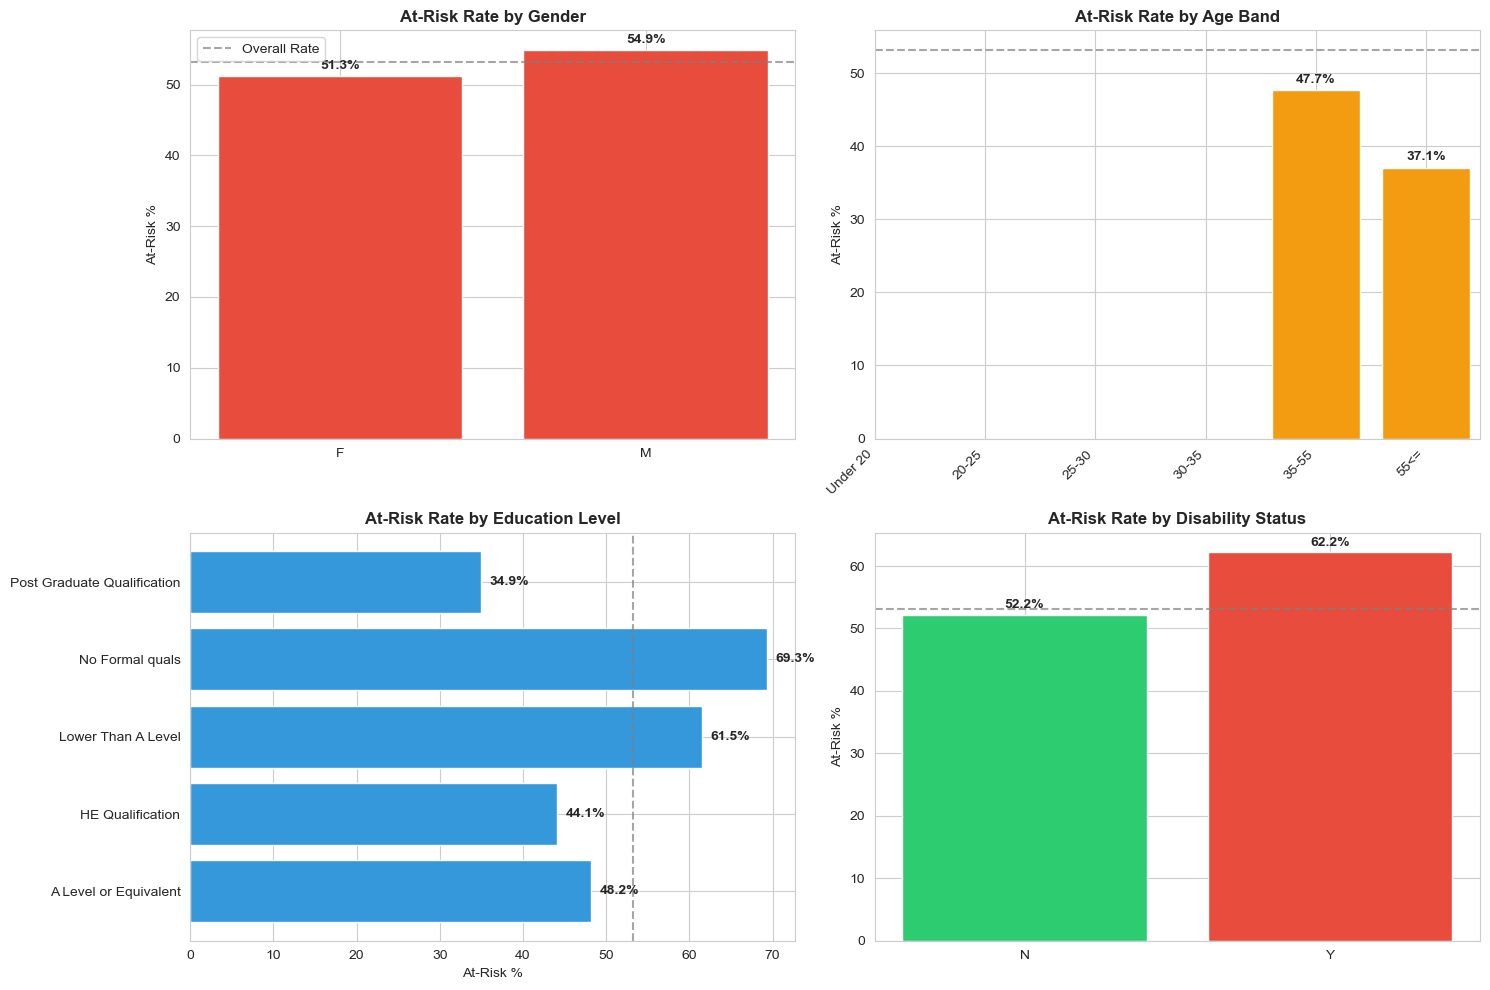

In [15]:
# At-risk rate visualization by demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# By gender
gender_data = df_at_risk.groupby('gender')['is_at_risk'].mean() * 100
axes[0, 0].bar(range(len(gender_data)), gender_data.values, color='#e74c3c')
axes[0, 0].set_xticks(range(len(gender_data)))
axes[0, 0].set_xticklabels(gender_data.index)
axes[0, 0].set_title('At-Risk Rate by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('At-Risk %')
axes[0, 0].axhline(y=df_at_risk['is_at_risk'].mean()*100, color='gray', linestyle='--', 
                    label='Overall Rate', alpha=0.7)
axes[0, 0].legend()
for i, v in enumerate(gender_data.values):
    axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# By age band
age_data = df_at_risk.groupby('age_band')['is_at_risk'].mean() * 100
age_data = age_data.reindex(age_order)
axes[0, 1].bar(range(len(age_data)), age_data.values, color='#f39c12')
axes[0, 1].set_xticks(range(len(age_data)))
axes[0, 1].set_xticklabels(age_data.index, rotation=45, ha='right')
axes[0, 1].set_title('At-Risk Rate by Age Band', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('At-Risk %')
axes[0, 1].axhline(y=df_at_risk['is_at_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
for i, v in enumerate(age_data.values):
    if not pd.isna(v):
        axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# By education
edu_data = df_at_risk.groupby('highest_education')['is_at_risk'].mean() * 100
axes[1, 0].barh(range(len(edu_data)), edu_data.values, color='#3498db')
axes[1, 0].set_yticks(range(len(edu_data)))
axes[1, 0].set_yticklabels(edu_data.index)
axes[1, 0].set_title('At-Risk Rate by Education Level', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('At-Risk %')
axes[1, 0].axvline(x=df_at_risk['is_at_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
for i, v in enumerate(edu_data.values):
    axes[1, 0].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

# By disability
disability_data = df_at_risk.groupby('disability')['is_at_risk'].mean() * 100
axes[1, 1].bar(range(len(disability_data)), disability_data.values, color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_xticks(range(len(disability_data)))
axes[1, 1].set_xticklabels(disability_data.index)
axes[1, 1].set_title('At-Risk Rate by Disability Status', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('At-Risk %')
axes[1, 1].axhline(y=df_at_risk['is_at_risk'].mean()*100, color='gray', linestyle='--', alpha=0.7)
for i, v in enumerate(disability_data.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Course Registration and Engagement by Module

In [16]:
print("Course Registration and Module Performance:")
print("=" * 70)

# Module analysis
print("\n1. MODULE STATISTICS:")
module_stats = df_student_registration.groupby('code_module').agg({
    'id_student': 'nunique',
    'code_presentation': 'nunique'
}).rename(columns={'id_student': 'Students', 'code_presentation': 'Presentations'})
print(module_stats)

# At-risk rate by module
print("\n2. AT-RISK RATE BY MODULE:")
module_at_risk = df_at_risk.groupby(
    df_at_risk['id_student'].isin(
        df_student_registration['id_student']
    ) & df_at_risk['id_student'].isin(
        df_student_info['id_student']
    )
)

# Better approach: merge data
reg_merged = df_student_registration.merge(df_at_risk[['id_student', 'is_at_risk']], on='id_student')
module_risk = reg_merged.groupby('code_module')['is_at_risk'].agg(['sum', 'count', 'mean'])
module_risk.columns = ['At-Risk Count', 'Total Students', 'At-Risk Rate']
module_risk['At-Risk Rate'] = module_risk['At-Risk Rate'] * 100
print(module_risk)

print("\n3. VLE ENGAGEMENT BY MODULE:")
vle_by_module = df_student_vle.groupby('code_module')['sum_click'].agg(['mean', 'median', 'max'])
vle_by_module.columns = ['Mean Clicks', 'Median Clicks', 'Max Clicks']
print(vle_by_module)

print("\n4. AVERAGE ASSESSMENT SCORE BY MODULE:")
assess_merged = df_student_assessment.merge(df_assessments[['id_assessment', 'code_module']], on='id_assessment')
score_by_module = assess_merged.groupby('code_module')['score'].agg(['mean', 'median', 'std'])
score_by_module.columns = ['Mean Score', 'Median Score', 'Std Dev']
print(score_by_module)

Course Registration and Module Performance:

1. MODULE STATISTICS:
             Students  Presentations
code_module                         
AAA               712              2
BBB              7692              4
CCC              4251              2
DDD              5848              4
EEE              2859              3
FFF              7397              4
GGG              2525              3

2. AT-RISK RATE BY MODULE:
             At-Risk Count  Total Students  At-Risk Rate
code_module                                             
AAA                    236             748     31.550802
BBB                   4226            7909     53.432798
CCC                   2806            4434     63.283717
DDD                   3923            6272     62.547832
EEE                   1670            2934     56.918882
FFF                   4356            7762     56.119557
GGG                   1052            2534     41.515391

3. VLE ENGAGEMENT BY MODULE:
             Mean Clicks  Med

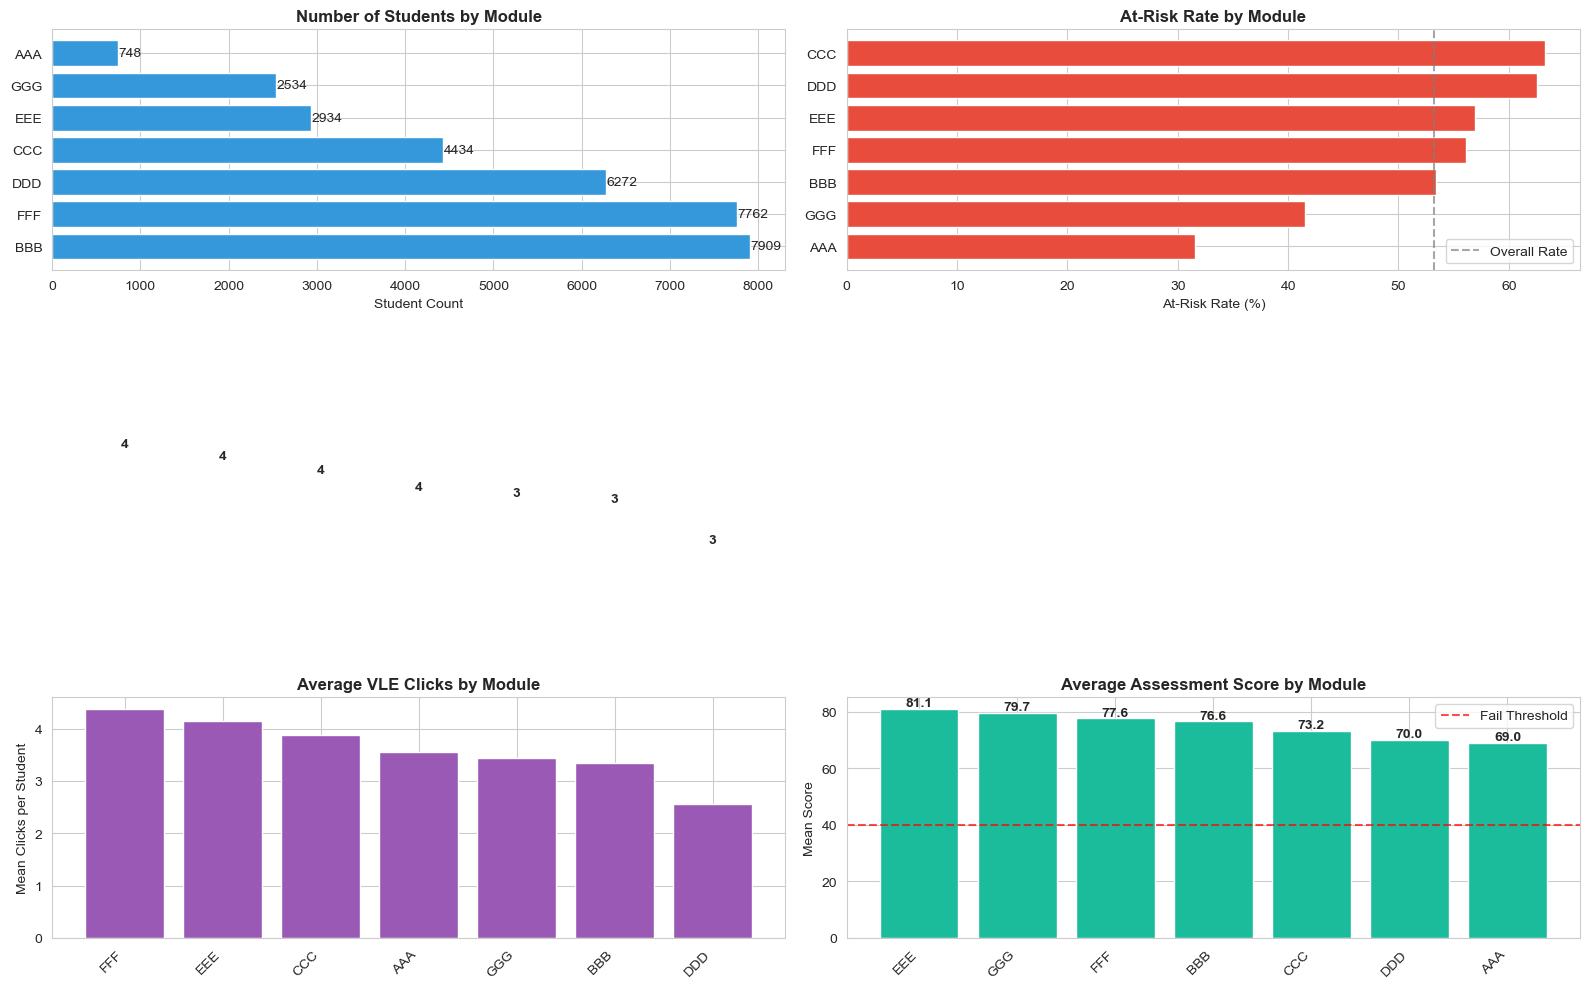

In [17]:
# Module analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Student count by module
module_students = df_student_registration['code_module'].value_counts()
axes[0, 0].barh(module_students.index, module_students.values, color='#3498db')
axes[0, 0].set_title('Number of Students by Module', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Student Count')
for i, v in enumerate(module_students.values):
    axes[0, 0].text(v + 5, i, str(v), va='center')

# At-risk rate by module
if 'At-Risk Rate' in module_risk.columns:
    module_risk_sorted = module_risk.sort_values('At-Risk Rate', ascending=True)
    colors_risk = ['#e74c3c' if x > 30 else '#f39c12' if x > 20 else '#2ecc71' 
                   for x in module_risk_sorted['At-Risk Rate']]
    axes[0, 1].barh(range(len(module_risk_sorted)), module_risk_sorted['At-Risk Rate'].values, color=colors_risk)
    axes[0, 1].set_yticks(range(len(module_risk_sorted)))
    axes[0, 1].set_yticklabels(module_risk_sorted.index)
    axes[0, 1].set_title('At-Risk Rate by Module', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('At-Risk Rate (%)')
    axes[0, 1].axvline(x=df_at_risk['is_at_risk'].mean()*100, color='gray', linestyle='--', 
                       label='Overall Rate', alpha=0.7)
    axes[0, 1].legend()

# VLE clicks by module
vle_module = df_student_vle.groupby('code_module')['sum_click'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(vle_module)), vle_module.values, color='#9b59b6')
axes[1, 0].set_xticks(range(len(vle_module)))
axes[1, 0].set_xticklabels(vle_module.index, rotation=45, ha='right')
axes[1, 0].set_title('Average VLE Clicks by Module', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Mean Clicks per Student')
for i, v in enumerate(vle_module.values):
    axes[1, 0].text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Assessment score by module
score_module = df_student_assessment.merge(df_assessments[['id_assessment', 'code_module']], 
                                           on='id_assessment').groupby('code_module')['score'].mean().sort_values(ascending=False)
axes[1, 1].bar(range(len(score_module)), score_module.values, color='#1abc9c')
axes[1, 1].set_xticks(range(len(score_module)))
axes[1, 1].set_xticklabels(score_module.index, rotation=45, ha='right')
axes[1, 1].set_title('Average Assessment Score by Module', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Score')
axes[1, 1].axhline(y=40, color='red', linestyle='--', label='Fail Threshold', alpha=0.7)
axes[1, 1].legend()
for i, v in enumerate(score_module.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Feature Relationships and Correlation Analysis

In [18]:
# Create a comprehensive feature dataset for correlation analysis
print("Building Correlation Features:")
print("=" * 70)

# Aggregate VLE engagement at student-module level
vle_agg = df_student_vle.groupby(['id_student', 'code_module']).agg({
    'sum_click': ['sum', 'mean', 'max'],
    'date': 'count'
}).reset_index()
vle_agg.columns = ['id_student', 'code_module', 'total_vle_clicks', 'avg_vle_clicks', 'max_vle_clicks', 'vle_activity_days']

# Aggregate assessment scores at student-module level
assess_agg = df_student_assessment.merge(
    df_assessments[['id_assessment', 'code_module']], 
    on='id_assessment'
).groupby(['id_student', 'code_module']).agg({
    'score': ['mean', 'min', 'max', 'count'],
    'is_banked': 'sum'
}).reset_index()
assess_agg.columns = ['id_student', 'code_module', 'avg_score', 'min_score', 'max_score', 'num_submissions', 'num_banked']

# Merge all features
correlation_data = df_student_registration.merge(vle_agg, on=['id_student', 'code_module'], how='left')
correlation_data = correlation_data.merge(assess_agg, on=['id_student', 'code_module'], how='left')
correlation_data = correlation_data.merge(df_at_risk[['id_student', 'is_at_risk']], on='id_student', how='left')

# Fill NaN values
correlation_data = correlation_data.fillna(0)

# Select numeric columns for correlation
numeric_cols = ['total_vle_clicks', 'avg_vle_clicks', 'max_vle_clicks', 'avg_score', 'num_submissions', 'is_at_risk']
correlation_matrix = correlation_data[numeric_cols].corr()

print("Features ready for correlation analysis")
print(f"\nCorrelation with At-Risk Status:")
print(correlation_matrix['is_at_risk'].sort_values(ascending=False))

Building Correlation Features:
Features ready for correlation analysis

Correlation with At-Risk Status:
is_at_risk          1.000000
max_vle_clicks     -0.176573
avg_vle_clicks     -0.315073
total_vle_clicks   -0.410485
avg_score          -0.554008
num_submissions    -0.614699
Name: is_at_risk, dtype: float64


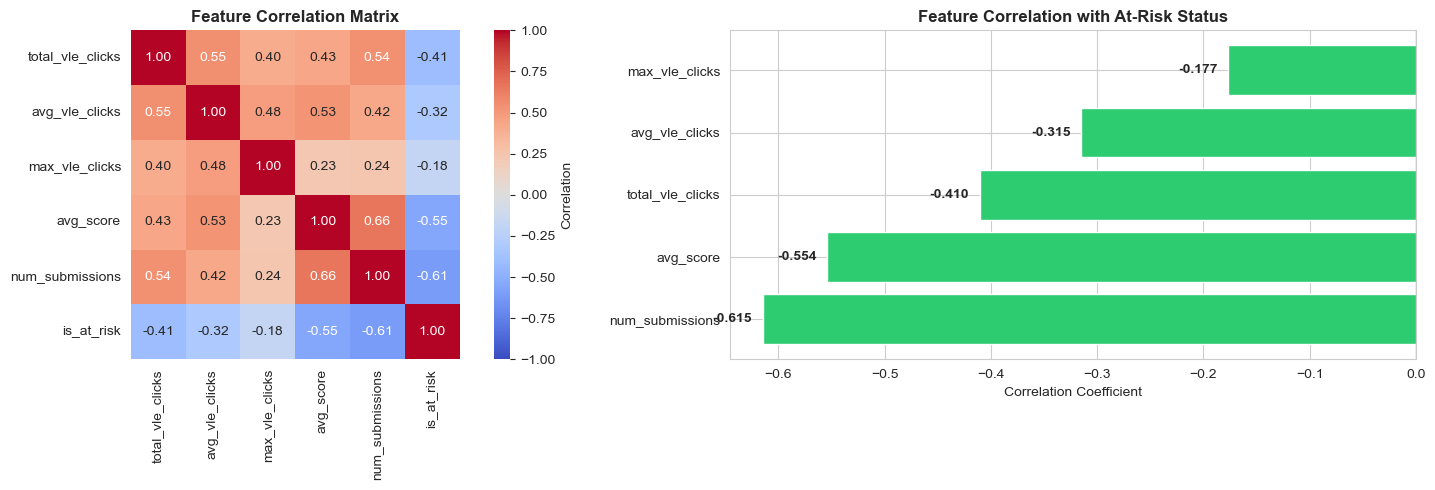

In [19]:
# Correlation visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
axes[0].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# Correlation with at-risk status
at_risk_corr = correlation_matrix['is_at_risk'].drop('is_at_risk').sort_values(ascending=True)
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in at_risk_corr.values]
axes[1].barh(range(len(at_risk_corr)), at_risk_corr.values, color=colors)
axes[1].set_yticks(range(len(at_risk_corr)))
axes[1].set_yticklabels(at_risk_corr.index)
axes[1].set_title('Feature Correlation with At-Risk Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(at_risk_corr.values):
    axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

## 8.1 Bivariate and Multivariate Analysis with Target

BIVARIATE ANALYSIS: TARGET VS CATEGORICAL FEATURES

Feature: gender
        count  at_risk_pct
gender                    
M       15046        54.91
F       13739        51.28

Feature: age_band
          count  at_risk_pct
age_band                    
0-35      20145        55.63
35-55      8462        47.67
55<=        178        37.08

Feature: highest_education
                             count  at_risk_pct
highest_education                              
No Formal quals                306        69.28
Lower Than A Level           11780        61.51
A Level or Equivalent        12355        48.22
HE Qualification              4092        44.09
Post Graduate Qualification    252        34.92

Feature: disability
            count  at_risk_pct
disability                    
Y            2717        62.24
N           26068        52.23

NUMERIC FEATURE MEAN COMPARISON (At-Risk vs Non-Risk):
                      non_risk_mean  at_risk_mean  difference
studied_credits               73.

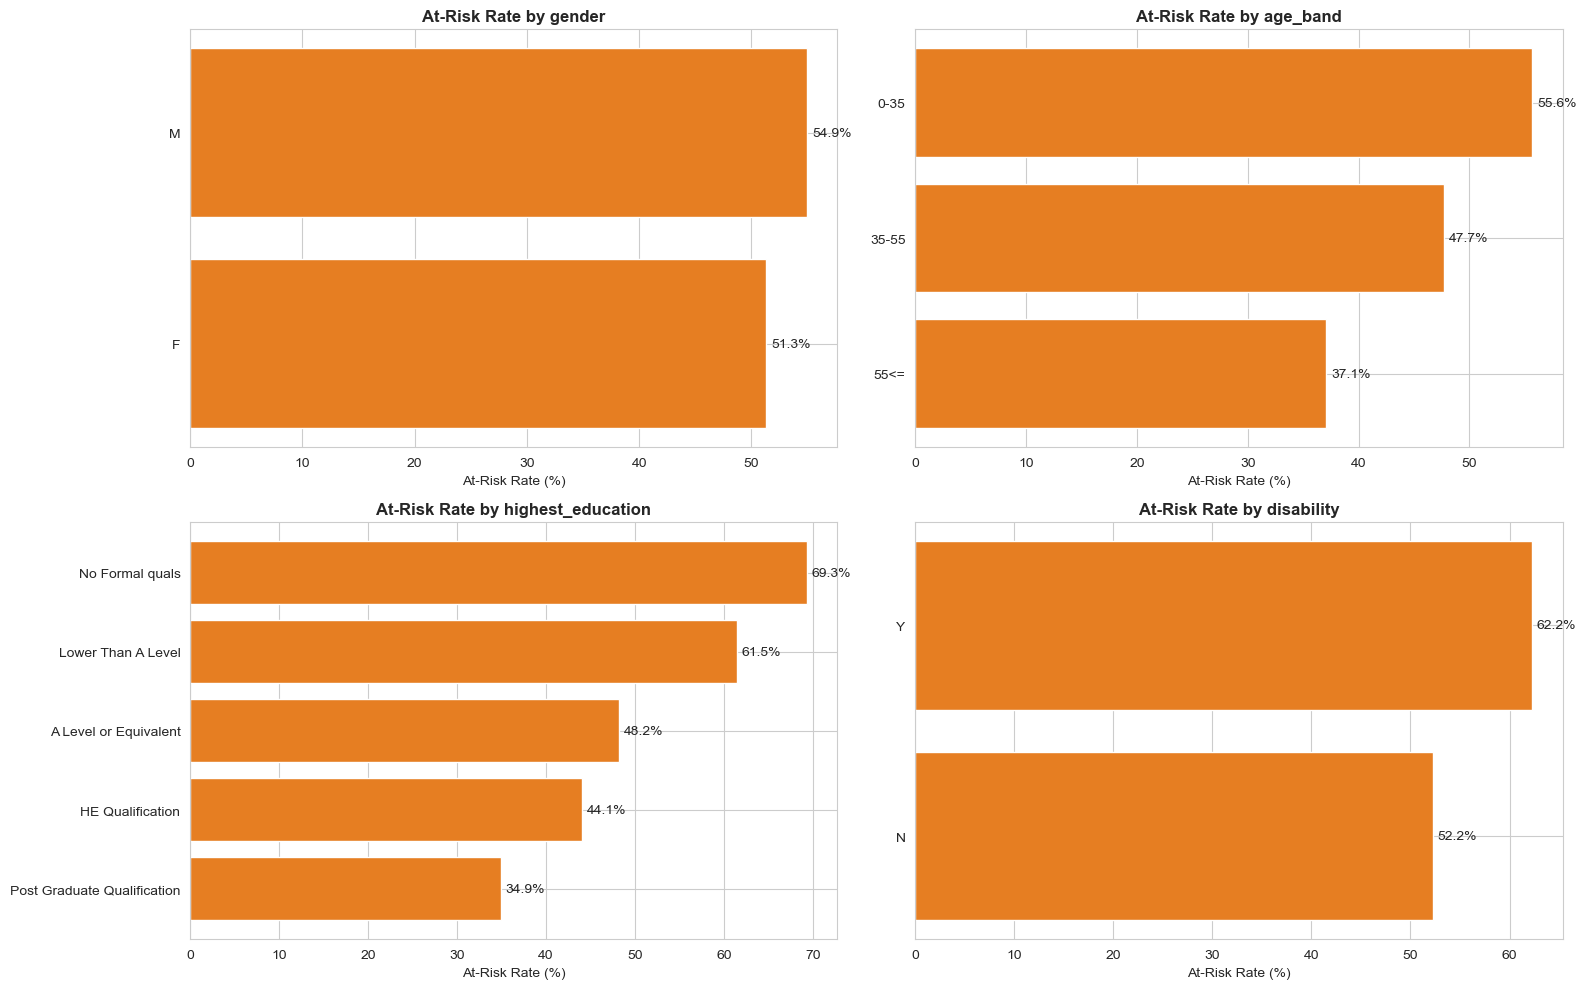

In [20]:
# Bivariate analysis: target vs specific variables
if 'is_at_risk' not in df_student_info.columns:
    df_student_info['is_at_risk'] = df_student_info['final_result'].isin(['Withdrawn', 'Fail']).astype(int)

bivariate_data = df_student_info.copy()

cat_features = ['gender', 'age_band', 'highest_education', 'disability']
bivariate_tables = {}

print('BIVARIATE ANALYSIS: TARGET VS CATEGORICAL FEATURES')
print('=' * 80)
for feature in cat_features:
    tbl = bivariate_data.groupby(feature)['is_at_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    tbl['at_risk_pct'] = tbl['mean'] * 100
    bivariate_tables[feature] = tbl
    print(f"\nFeature: {feature}")
    print(tbl[['count', 'at_risk_pct']].round(2))

# Numeric feature relationships with target
num_features = ['studied_credits', 'num_of_prev_attempts']
num_summary = bivariate_data.groupby('is_at_risk')[num_features].mean().T
num_summary.columns = ['non_risk_mean', 'at_risk_mean']
num_summary['difference'] = num_summary['at_risk_mean'] - num_summary['non_risk_mean']

print('\nNUMERIC FEATURE MEAN COMPARISON (At-Risk vs Non-Risk):')
print(num_summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, feature in enumerate(cat_features):
    r, c = divmod(idx, 2)
    plot_data = bivariate_tables[feature].sort_values('at_risk_pct', ascending=True)
    axes[r, c].barh(plot_data.index.astype(str), plot_data['at_risk_pct'], color='#e67e22')
    axes[r, c].set_title(f'At-Risk Rate by {feature}', fontweight='bold')
    axes[r, c].set_xlabel('At-Risk Rate (%)')
    for i, v in enumerate(plot_data['at_risk_pct'].values):
        axes[r, c].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

MULTIVARIATE ANALYSIS: INTERACTION EFFECTS

At-risk rate by VLE band x Score band (%):
score_band  Q1 Low     Q2     Q3  Q4 High
vle_band                                 
Q1 Low       99.54  90.07  78.67    86.29
Q2           97.60  70.81  51.18    42.42
Q3           89.09  55.00  35.41    21.49
Q4 High      79.79  45.33  22.84    13.16

Top high-risk combinations (VLE band x submission band):
   vle_band submission_band  at_risk_pct
0    Q1 Low          Q1 Low        99.67
4        Q2          Q1 Low        99.55
8        Q3          Q1 Low        98.71
1    Q1 Low              Q2        95.11
12  Q4 High          Q1 Low        91.67
5        Q2              Q2        88.86
9        Q3              Q2        58.95
2    Q1 Low              Q3        57.76


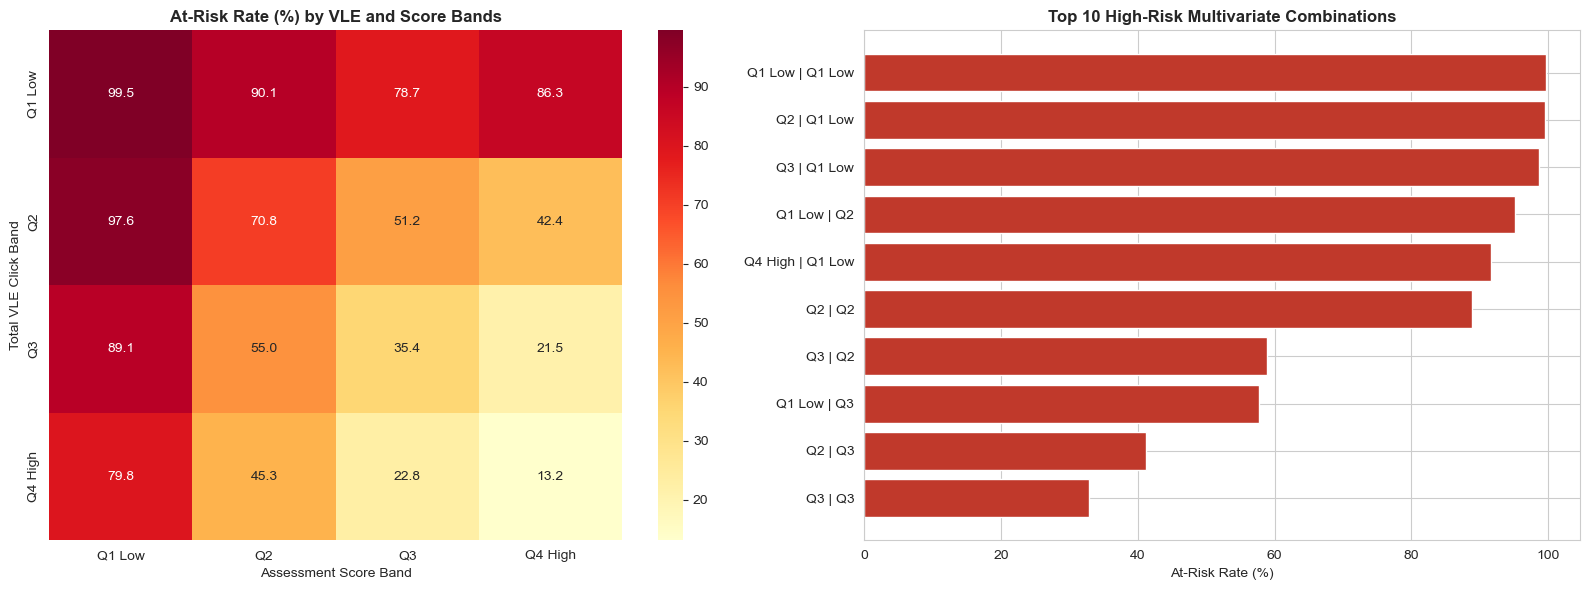

In [21]:
# Multivariate analysis: interaction effects with target
if 'correlation_data' not in globals():
    vle_agg = df_student_vle.groupby(['id_student', 'code_module']).agg({
        'sum_click': ['sum', 'mean', 'max'],
        'date': 'count'
    }).reset_index()
    vle_agg.columns = ['id_student', 'code_module', 'total_vle_clicks', 'avg_vle_clicks', 'max_vle_clicks', 'vle_activity_days']

    assess_agg = df_student_assessment.merge(
        df_assessments[['id_assessment', 'code_module']],
        on='id_assessment'
    ).groupby(['id_student', 'code_module']).agg({
        'score': ['mean', 'count']
    }).reset_index()
    assess_agg.columns = ['id_student', 'code_module', 'avg_score', 'num_submissions']

    correlation_data = df_student_registration.merge(vle_agg, on=['id_student', 'code_module'], how='left')
    correlation_data = correlation_data.merge(assess_agg, on=['id_student', 'code_module'], how='left')
    correlation_data = correlation_data.merge(df_student_info[['id_student', 'is_at_risk']], on='id_student', how='left')
    correlation_data = correlation_data.fillna(0)

mv = correlation_data.copy()

# Create quantile bands for interaction analysis
mv['vle_band'] = pd.qcut(mv['total_vle_clicks'].rank(method='first'), q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
mv['score_band'] = pd.qcut(mv['avg_score'].rank(method='first'), q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])
mv['submission_band'] = pd.qcut(mv['num_submissions'].rank(method='first'), q=4, labels=['Q1 Low', 'Q2', 'Q3', 'Q4 High'])

interaction_heatmap = mv.pivot_table(
    index='vle_band',
    columns='score_band',
    values='is_at_risk',
    aggfunc='mean'
 ) * 100

triple_summary = mv.groupby(['vle_band', 'submission_band'])['is_at_risk'].mean().reset_index()
triple_summary['at_risk_pct'] = triple_summary['is_at_risk'] * 100

print('MULTIVARIATE ANALYSIS: INTERACTION EFFECTS')
print('=' * 80)
print('\nAt-risk rate by VLE band x Score band (%):')
print(interaction_heatmap.round(2))

print('\nTop high-risk combinations (VLE band x submission band):')
print(triple_summary[['vle_band', 'submission_band', 'at_risk_pct']].sort_values('at_risk_pct', ascending=False).head(8).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(interaction_heatmap, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('At-Risk Rate (%) by VLE and Score Bands', fontweight='bold')
axes[0].set_xlabel('Assessment Score Band')
axes[0].set_ylabel('Total VLE Click Band')

plot_top = triple_summary.sort_values('at_risk_pct', ascending=False).head(10)
plot_labels = plot_top['vle_band'].astype(str) + ' | ' + plot_top['submission_band'].astype(str)
axes[1].barh(plot_labels, plot_top['at_risk_pct'], color='#c0392b')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 High-Risk Multivariate Combinations', fontweight='bold')
axes[1].set_xlabel('At-Risk Rate (%)')

plt.tight_layout()
plt.show()

## 8.2 General Bivariate and Multivariate Analysis

GENERAL BIVARIATE AND MULTIVARIATE ANALYSIS (NON-TARGET)

Bivariate summaries:
1) total_vle_clicks vs avg_score correlation:
                  total_vle_clicks  avg_score
total_vle_clicks             1.000      0.393
avg_score                    0.393      1.000

2) Mean total_vle_clicks by highest_education:
highest_education
Post Graduate Qualification    2343.06
HE Qualification               1822.91
A Level or Equivalent          1461.65
Lower Than A Level             1269.87
No Formal quals                 986.66
Name: total_vle_clicks, dtype: float64

3) Mean studied_credits by age_band:
age_band
0-35     80.66
35-55    74.12
55<=     73.57
Name: studied_credits, dtype: float64

Multivariate correlation matrix (non-target):
                      total_vle_clicks  avg_score  num_submissions  \
total_vle_clicks                 1.000      0.393            0.580   
avg_score                        0.393      1.000            0.587   
num_submissions                  0.580      0.587 

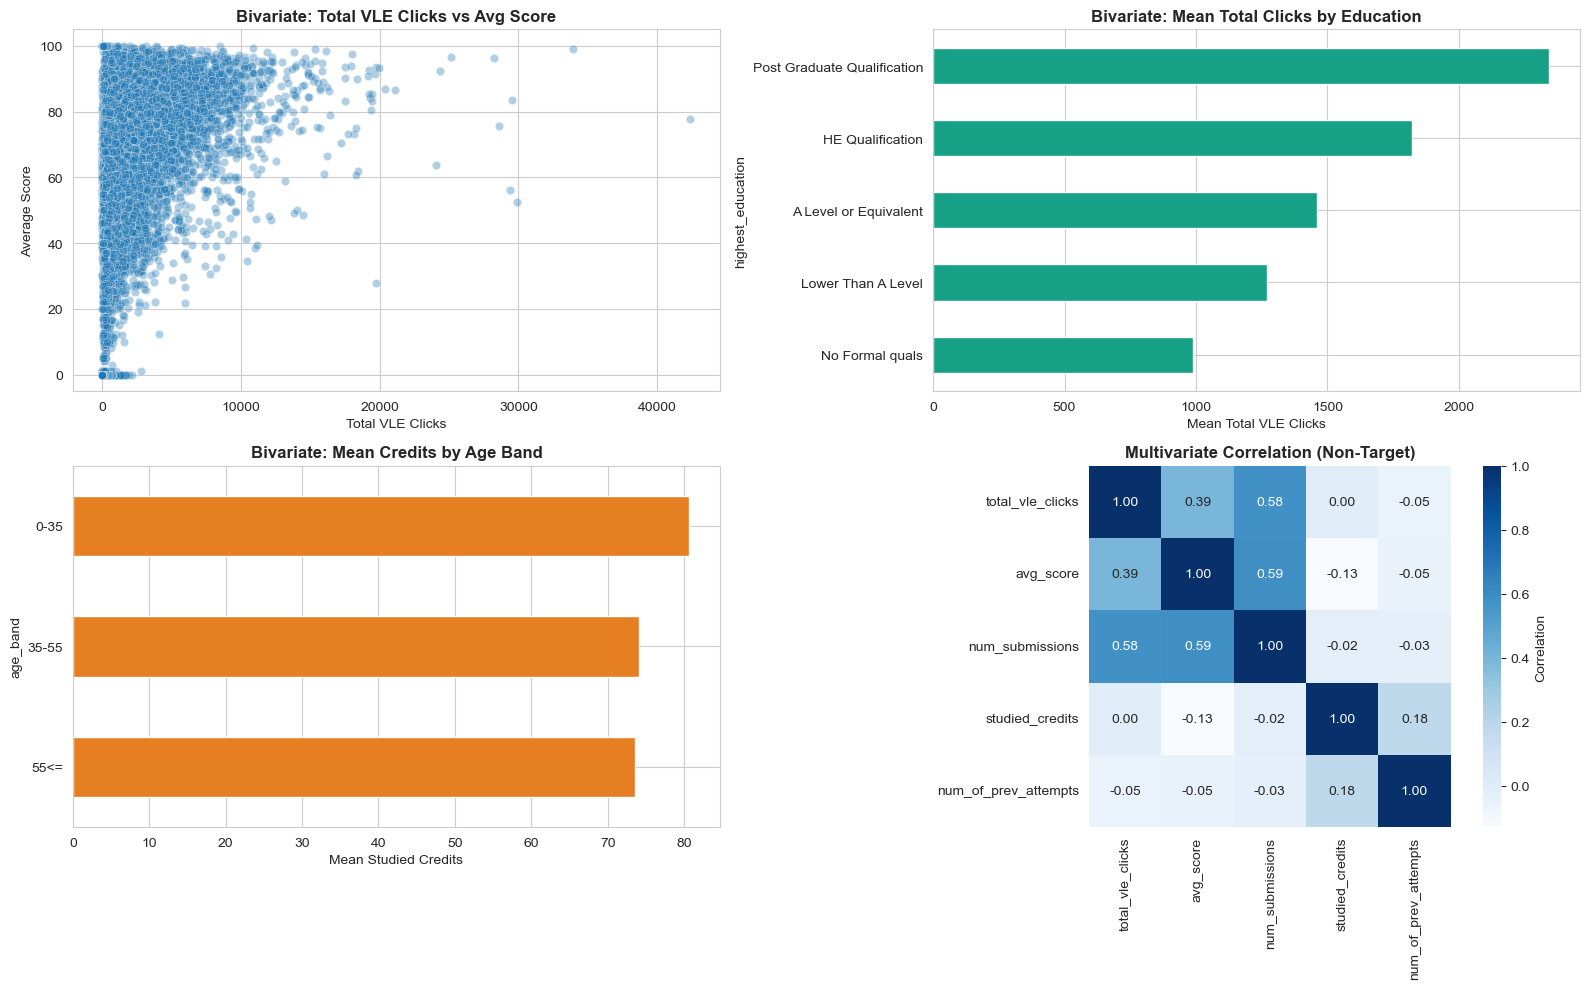

In [23]:
# General bivariate and multivariate analysis without target variable
if 'correlation_data' not in globals():
    vle_agg = df_student_vle.groupby(['id_student', 'code_module']).agg({
        'sum_click': ['sum', 'mean', 'max'],
        'date': 'count'
    }).reset_index()
    vle_agg.columns = ['id_student', 'code_module', 'total_vle_clicks', 'avg_vle_clicks', 'max_vle_clicks', 'vle_activity_days']

    assess_agg = df_student_assessment.merge(
        df_assessments[['id_assessment', 'code_module']],
        on='id_assessment'
    ).groupby(['id_student', 'code_module']).agg({
        'score': ['mean', 'count']
    }).reset_index()
    assess_agg.columns = ['id_student', 'code_module', 'avg_score', 'num_submissions']

    correlation_data = df_student_registration.merge(vle_agg, on=['id_student', 'code_module'], how='left')
    correlation_data = correlation_data.merge(assess_agg, on=['id_student', 'code_module'], how='left')
    correlation_data = correlation_data.fillna(0)

# Move to student-level features for non-target exploration
student_level = correlation_data.groupby('id_student').agg({
    'total_vle_clicks': 'sum',
    'avg_score': 'mean',
    'num_submissions': 'sum'
}).reset_index()

general_eda = student_level.merge(
    df_student_info[['id_student', 'age_band', 'highest_education', 'studied_credits', 'num_of_prev_attempts']],
    on='id_student',
    how='left'
 )

print('GENERAL BIVARIATE AND MULTIVARIATE ANALYSIS (NON-TARGET)')
print('=' * 85)

print('\nBivariate summaries:')
print('1) total_vle_clicks vs avg_score correlation:')
print(general_eda[['total_vle_clicks', 'avg_score']].corr().round(3))

edu_clicks = general_eda.groupby('highest_education')['total_vle_clicks'].mean().sort_values(ascending=False)
age_credits = general_eda.groupby('age_band')['studied_credits'].mean().sort_values(ascending=False)

print('\n2) Mean total_vle_clicks by highest_education:')
print(edu_clicks.round(2))
print('\n3) Mean studied_credits by age_band:')
print(age_credits.round(2))

multi_cols = ['total_vle_clicks', 'avg_score', 'num_submissions', 'studied_credits', 'num_of_prev_attempts']
general_corr = general_eda[multi_cols].corr()

print('\nMultivariate correlation matrix (non-target):')
print(general_corr.round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Bivariate: numeric-numeric
sns.scatterplot(data=general_eda, x='total_vle_clicks', y='avg_score', alpha=0.35, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Bivariate: Total VLE Clicks vs Avg Score', fontweight='bold')
axes[0, 0].set_xlabel('Total VLE Clicks')
axes[0, 0].set_ylabel('Average Score')

# Bivariate: categorical-numeric
edu_clicks.sort_values().plot(kind='barh', ax=axes[0, 1], color='#16a085')
axes[0, 1].set_title('Bivariate: Mean Total Clicks by Education', fontweight='bold')
axes[0, 1].set_xlabel('Mean Total VLE Clicks')

age_credits.sort_values().plot(kind='barh', ax=axes[1, 0], color='#e67e22')
axes[1, 0].set_title('Bivariate: Mean Credits by Age Band', fontweight='bold')
axes[1, 0].set_xlabel('Mean Studied Credits')

# Multivariate: non-target correlation heatmap
sns.heatmap(general_corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[1, 1], square=True, cbar_kws={'label': 'Correlation'})
axes[1, 1].set_title('Multivariate Correlation (Non-Target)', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Key Insights and Findings

In [22]:
print("KEY INSIGHTS AND FINDINGS")
print("=" * 80)

print("\n1. AT-RISK STUDENT DISTRIBUTION:")
print("   • Total at-risk students: {} ({:.1f}%)".format(
    df_at_risk['is_at_risk'].sum(), 
    df_at_risk['is_at_risk'].mean() * 100
))
print("   • Withdrawn: {} students".format((df_student_info['final_result'] == 'Withdrawn').sum()))
print("   • Failed: {} students".format((df_student_info['final_result'] == 'Fail').sum()))

print("\n2. ENGAGEMENT PATTERNS:")
at_risk_students = df_at_risk[df_at_risk['is_at_risk'] == 1]['id_student'].values
non_risk_students = df_at_risk[df_at_risk['is_at_risk'] == 0]['id_student'].values

at_risk_vle = df_student_vle[df_student_vle['id_student'].isin(at_risk_students)]['sum_click'].mean()
non_risk_vle = df_student_vle[df_student_vle['id_student'].isin(non_risk_students)]['sum_click'].mean()
print("   • At-risk students VLE clicks (avg): {:.1f}".format(at_risk_vle))
print("   • Non-risk students VLE clicks (avg): {:.1f}".format(non_risk_vle))
print("   • Difference: {:.1f}% lower engagement in at-risk".format(
    (1 - at_risk_vle / non_risk_vle) * 100
))

at_risk_score = assess_by_outcome[assess_by_outcome['final_result'].isin(['Withdrawn', 'Fail'])]['score'].mean()
pass_score = assess_by_outcome[assess_by_outcome['final_result'].isin(['Pass', 'Distinction'])]['score'].mean()
print("   • At-risk students avg assessment score: {:.2f}".format(at_risk_score))
print("   • Successful students avg assessment score: {:.2f}".format(pass_score))

print("\n3. DEMOGRAPHIC RISK FACTORS:")
gender_risk = df_at_risk.groupby('gender')['is_at_risk'].mean().sort_values(ascending=False)
print("   • Gender with highest risk: {} ({:.1f}%)".format(
    gender_risk.idxmax(), 
    gender_risk.max() * 100
))

age_risk = df_at_risk.groupby('age_band')['is_at_risk'].mean().sort_values(ascending=False)
print("   • Age band with highest risk: {} ({:.1f}%)".format(
    age_risk.idxmax() if not pd.isna(age_risk.idxmax()) else 'N/A', 
    age_risk.max() * 100 if not pd.isna(age_risk.max()) else 0
))

disability_risk = df_at_risk[df_at_risk['disability'] == 'Y']['is_at_risk'].mean()
print("   • At-risk rate for students with disabilities: {:.1f}%".format(disability_risk * 100))

print("\n4. STRONGEST PREDICTIVE FEATURES:")
print("   Features most correlated with at-risk status:")
at_risk_corr_top = correlation_matrix['is_at_risk'].drop('is_at_risk').abs().sort_values(ascending=False)
for i, (feature, corr_val) in enumerate(at_risk_corr_top.head(5).items(), 1):
    actual_corr = correlation_matrix.loc[feature, 'is_at_risk']
    direction = "increases" if actual_corr > 0 else "decreases"
    print("   {}: {} (correlation: {:.3f})".format(i, feature, actual_corr))

print("\n5. DATA QUALITY SUMMARY:")
print("   • Total students analyzed: {}".format(len(df_student_info)))
print("   • Total registrations: {}".format(len(df_student_registration)))
print("   • Total VLE interactions: {}".format(len(df_student_vle)))
print("   • Total assessments submitted: {}".format(len(df_student_assessment)))
print("   • Coverage: All students have demographics, {} have VLE data, {} have assessment data".format(
    len(df_student_vle['id_student'].unique()),
    len(df_student_assessment['id_student'].unique())
))

KEY INSIGHTS AND FINDINGS

1. AT-RISK STUDENT DISTRIBUTION:
   • Total at-risk students: 15307 (53.2%)
   • Withdrawn: 9043 students
   • Failed: 6264 students

2. ENGAGEMENT PATTERNS:
   • At-risk students VLE clicks (avg): 3.5
   • Non-risk students VLE clicks (avg): 3.8
   • Difference: 7.5% lower engagement in at-risk
   • At-risk students avg assessment score: 66.71
   • Successful students avg assessment score: 79.32

3. DEMOGRAPHIC RISK FACTORS:
   • Gender with highest risk: M (54.9%)
   • Age band with highest risk: 0-35 (55.6%)
   • At-risk rate for students with disabilities: 62.2%

4. STRONGEST PREDICTIVE FEATURES:
   Features most correlated with at-risk status:
   1: num_submissions (correlation: -0.615)
   2: avg_score (correlation: -0.554)
   3: total_vle_clicks (correlation: -0.410)
   4: avg_vle_clicks (correlation: -0.315)
   5: max_vle_clicks (correlation: -0.177)

5. DATA QUALITY SUMMARY:
   • Total students analyzed: 28785
   • Total registrations: 32593
   • Tota